# checkpoint 6

доработка ml-части: очистка текстов, удаление шаблонов каналов, новые признаки, rnn, transformer, кластеры и summary.

в проекте уже есть telegram parser: [parser.py](../aggregate_bot_modules/parser-module/parser.py). ниже ячейка для его запуска, по умолчанию сбор выключен.

In [1]:
from pathlib import Path
import sys
import os
import subprocess

cwd = Path.cwd().resolve()
root = cwd if (cwd / 'aggregate_bot_modules').exists() else cwd.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

parser_path = root / 'aggregate_bot_modules' / 'parser-module' / 'parser.py'
parser_path

PosixPath('/Users/yaroslavsledevskiy/Downloads/aggregator-bot-main/aggregate_bot_modules/parser-module/parser.py')

In [2]:
run_parser = False
channel = '@rbc_news'
limit = 1000
out_path = root / 'data' / 'rbc_news_checkpoint.csv'

if run_parser:
    cmd = [
        sys.executable,
        str(parser_path),
        '--channel', channel,
        '--limit', str(limit),
        '--out', str(out_path),
    ]
    subprocess.run(cmd, check=True)
else:
    print('parser call is ready, set run_parser = True when telegram credentials are configured')

parser call is ready, set run_parser = True when telegram credentials are configured


проверка зависимостей для запуска ноутбука.

In [3]:
import importlib.util
import subprocess

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
    'gensim': 'gensim',
    'torch': 'torch',
    'transformers': 'transformers',
    'accelerate': 'accelerate',
}

missing = [pip_name for module_name, pip_name in required_packages.items() if importlib.util.find_spec(module_name) is None]
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)
    print('installed:', ', '.join(missing))
else:
    print('all dependencies are installed')

all dependencies are installed


берем основной корпус `data/raw/*.csv`. после базовой очистки удаляем частые фразы внутри каждого канала и дальше работаем с `text_clean_no_templates`.

In [4]:
import re
import math
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize, Normalizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import accuracy_score, f1_score, silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 120)
RUS_STOP_WORDS = {
    'и','в','во','не','что','он','на','я','с','со','как','а','то','все','она','так','его','но','да','ты','к','у','же','вы','за','бы','по','только','ее','мне','было','вот','от','меня','еще','нет','о','из','ему','теперь','когда','даже','ну','вдруг','ли','если','уже','или','ни','быть','был','него','до','вас','нибудь','опять','уж','вам','ведь','там','потом','себя','ничего','ей','может','они','тут','где','есть','надо','ней','для','мы','тебя','их','чем','была','сам','чтоб','без','будто','чего','раз','тоже','себе','под','будет','ж','тогда','кто','этот','того','потому','этого','какой','совсем','ним','здесь','этом','один','почти','мой','тем','чтобы','нее','сейчас','были','куда','зачем','всех','никогда','можно','при','наконец','два','об','другой','хоть','после','над','больше','тот','через','эти','нас','про','всего','них','какая','много','разве','три','эту','моя','впрочем','свою','этой','перед','иногда','лучше','чуть','том','нельзя','такой','им','более','всегда','конечно','всю','между','это','года','год','лет','день','сегодня','вчера','завтра'
}
TECH_STOP_WORDS = {
    'telegram','канал','подписаться','подписывайтесь','сайт','vpn','whatsapp','youtube','рассылка','max','tg','id','user','cas','ban','banned','reason','has','been','startapp','combot','забанен','причина','бан','https','http','www','com','me','t','ru','news','новости','риа','rt'
}
STOP_WORDS = sorted(RUS_STOP_WORDS | TECH_STOP_WORDS)


In [5]:
url_re = re.compile(r'http\S+|www\.\S+|t\.me/\S+')
mention_re = re.compile(r'@\w+')
hashtag_re = re.compile(r'#\w+')
non_letters_re = re.compile(r'[^a-zA-Zа-яА-ЯёЁ\s]')

TEXT_COL = 'text_clean_no_templates'

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = url_re.sub(' ', text)
    text = mention_re.sub(' ', text)
    text = hashtag_re.sub(' ', text)
    text = non_letters_re.sub(' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def extract_ngrams(text, n_min=3, n_max=8):
    words = str(text).split()
    for n in range(n_min, min(n_max, len(words)) + 1):
        for i in range(len(words) - n + 1):
            yield ' '.join(words[i:i + n])

def find_templates(texts, threshold=0.35, min_count=25, max_templates=40):
    texts = [str(text) for text in texts if isinstance(text, str) or str(text)]
    if not texts:
        return []
    counts = Counter()
    for text in texts:
        counts.update(set(extract_ngrams(text)))
    templates = []
    for phrase, count in counts.items():
        if count >= min_count and count / len(texts) >= threshold:
            templates.append((phrase, count, count / len(texts)))
    templates = sorted(templates, key=lambda item: (len(item[0].split()), item[1]), reverse=True)
    return templates[:max_templates]

def remove_templates(text, templates):
    cleaned = str(text)
    for phrase, _, _ in sorted(templates, key=lambda item: len(item[0]), reverse=True):
        cleaned = cleaned.replace(phrase, ' ')
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

def clean_channel_templates(df):
    df = df.copy()
    if 'channel' not in df.columns:
        df[TEXT_COL] = df['text_clean']
        return df, pd.DataFrame(columns=['channel', 'template', 'count', 'share'])

    reports = []
    df[TEXT_COL] = df['text_clean']
    for channel, part in df.groupby('channel'):
        templates = find_templates(part['text_clean'].tolist())
        for phrase, count, share in templates[:10]:
            reports.append({'channel': channel, 'template': phrase, 'count': count, 'share': round(share, 3)})
        if templates:
            idx = part.index
            cleaned = df.loc[idx, 'text_clean'].map(lambda text: remove_templates(text, templates))
            df.loc[idx, TEXT_COL] = cleaned.where(cleaned.str.len() >= 15, df.loc[idx, 'text_clean'])
    return df, pd.DataFrame(reports)

def load_labeled_data():
    raw_dir = root / 'data' / 'raw'
    raw_files = sorted(raw_dir.glob('*.csv')) if raw_dir.exists() else []
    raw_parts = []
    for path in raw_files:
        part = pd.read_csv(path)
        if 'text' in part.columns and 'topic' in part.columns:
            raw_parts.append(part)

    if raw_parts:
        df = pd.concat(raw_parts, ignore_index=True)
        source = f'data/raw/*.csv, files={len(raw_parts)}'
    else:
        split_dir = root / 'data' / 'splits'
        if (split_dir / 'train.csv').exists() and (split_dir / 'val.csv').exists():
            parts = []
            for name in ['train.csv', 'val.csv', 'test.csv']:
                path = split_dir / name
                if path.exists():
                    parts.append(pd.read_csv(path))
            df = pd.concat(parts, ignore_index=True)
            source = 'data/splits/*.csv'
        elif (root / 'data' / 'processed_posts.csv').exists():
            df = pd.read_csv(root / 'data' / 'processed_posts.csv')
            source = 'data/processed_posts.csv'
        else:
            df = pd.read_csv(root / 'ML' / 'raw_posts_labeled.csv')
            source = 'ML/raw_posts_labeled.csv'

    if 'topic' not in df.columns or 'text' not in df.columns:
        raise ValueError('нужны колонки text и topic')

    df = df.dropna(subset=['text', 'topic']).copy()
    df['text'] = df['text'].astype(str)
    df['topic'] = df['topic'].astype(str)
    if 'text_clean' not in df.columns:
        df['text_clean'] = df['text'].map(clean_text)
    df = df[df['text_clean'].str.len() >= 15]
    df = df.drop_duplicates(subset=['text_clean', 'topic']).reset_index(drop=True)
    df, template_report = clean_channel_templates(df)
    df.attrs['source'] = source
    df.attrs['template_report'] = template_report
    return df

def make_split(df, test_size=0.15, val_size=0.15, random_state=42):
    stratify = df['topic'] if df['topic'].value_counts().min() >= 2 else None
    train_val, test = train_test_split(df, test_size=test_size, random_state=random_state, stratify=stratify)
    val_rel_size = val_size / (1 - test_size)
    stratify_tv = train_val['topic'] if train_val['topic'].value_counts().min() >= 2 else None
    train, val = train_test_split(train_val, test_size=val_rel_size, random_state=random_state, stratify=stratify_tv)
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

df = load_labeled_data()
train, val, test = make_split(df)
template_report = df.attrs.get('template_report')

print('source:', df.attrs.get('source'))
print('rows:', len(df))
print('train:', len(train), 'val:', len(val), 'test:', len(test))
print('text column:', TEXT_COL)
print('templates found:', len(template_report))
display(df['topic'].value_counts().to_frame('count'))
template_report.head(10)

source: data/raw/*.csv, files=13
rows: 10895
train: 7625 val: 1635 test: 1635
text column: text_clean_no_templates
templates found: 52


,count
topic,
politics,3638
economy,2676
it,2287
science,1325
sport,969


,channel,template,count,share
0,@bbcrussian,сайт без vpn telegram whatsapp youtube рассылка,850,0.916
1,@bbcrussian,сайт без vpn telegram whatsapp youtube,850,0.916
2,@bbcrussian,без vpn telegram whatsapp youtube рассылка,850,0.916
3,@bbcrussian,vpn telegram whatsapp youtube рассылка,850,0.916
4,@bbcrussian,сайт без vpn telegram whatsapp,850,0.916
5,@bbcrussian,без vpn telegram whatsapp youtube,850,0.916
6,@bbcrussian,telegram whatsapp youtube рассылка,861,0.928
7,@bbcrussian,сайт без vpn telegram,850,0.916
8,@bbcrussian,без vpn telegram whatsapp,850,0.916
9,@bbcrussian,vpn telegram whatsapp youtube,850,0.916


сравниваем представления текста: count, char n-grams, hashing, lsa, word2vec и fasttext. для словарных методов используем стоп-слова.

In [6]:
le = LabelEncoder()
y_train = le.fit_transform(train['topic'])
y_val = le.transform(val['topic'])
x_train_text = train[TEXT_COL].astype(str)
x_val_text = val[TEXT_COL].astype(str)

results = []

def eval_sparse(name, vectorizer, model):
    t0 = time.perf_counter()
    x_train = vectorizer.fit_transform(x_train_text)
    x_val = vectorizer.transform(x_val_text)
    feature_time = time.perf_counter() - t0
    t1 = time.perf_counter()
    model.fit(x_train, y_train)
    train_time = time.perf_counter() - t1
    pred = model.predict(x_val)
    results.append({
        'representation': name,
        'classifier': model.__class__.__name__,
        'features': x_train.shape[1],
        'f1_macro': f1_score(y_val, pred, average='macro'),
        'accuracy': accuracy_score(y_val, pred),
        'feature_time_sec': feature_time,
        'train_time_sec': train_time,
    })

eval_sparse('count_word_unigram', CountVectorizer(ngram_range=(1, 1), min_df=2, max_features=20000, stop_words=STOP_WORDS), LogisticRegression(max_iter=2000, n_jobs=-1))
eval_sparse('char_wb_3_5', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_features=50000), LinearSVC(C=1.0, dual='auto'))
eval_sparse('hashing_word_2pow18', HashingVectorizer(n_features=2**18, alternate_sign=False), LogisticRegression(max_iter=2000, n_jobs=-1))
eval_sparse('lsa_tfidf_svd', make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000, stop_words=STOP_WORDS), TruncatedSVD(n_components=min(200, max(2, len(train) - 1)), random_state=42), Normalizer(copy=False)), LogisticRegression(max_iter=2000, n_jobs=-1))

pd.DataFrame(results).sort_values('f1_macro', ascending=False)

,representation,classifier,features,f1_macro,accuracy,feature_time_sec,train_time_sec
1,char_wb_3_5,LinearSVC,50000,0.880668,0.866055,2.246029,0.874799
3,lsa_tfidf_svd,LogisticRegression,200,0.848041,0.833639,3.578746,0.610925
0,count_word_unigram,LogisticRegression,20000,0.847265,0.839755,0.224232,0.997055
2,hashing_word_2pow18,LogisticRegression,262144,0.826297,0.824465,0.145738,6.302260


In [7]:
def tokenize(text):
    return [token for token in str(text).split() if len(token) > 1]

def mean_embedding(tokens, model, dim):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if not vectors:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vectors, axis=0)

def eval_gensim(kind, vector_size=100):
    from gensim.models import Word2Vec, FastText
    cls = Word2Vec if kind == 'word2vec' else FastText
    train_tokens = x_train_text.map(tokenize).tolist()
    val_tokens = x_val_text.map(tokenize).tolist()
    model = cls(sentences=train_tokens, vector_size=vector_size, window=5, min_count=2, workers=4, sg=1, epochs=8, seed=42)
    x_train = np.vstack([mean_embedding(tokens, model, vector_size) for tokens in train_tokens])
    x_val = np.vstack([mean_embedding(tokens, model, vector_size) for tokens in val_tokens])
    clf = LogisticRegression(max_iter=2000, n_jobs=-1)
    clf.fit(x_train, y_train)
    pred = clf.predict(x_val)
    return {
        'representation': f'{kind}_mean_{vector_size}',
        'classifier': 'LogisticRegression',
        'features': vector_size,
        'f1_macro': f1_score(y_val, pred, average='macro'),
        'accuracy': accuracy_score(y_val, pred),
    }

for kind in ['word2vec', 'fasttext']:
    try:
        results.append(eval_gensim(kind))
    except Exception as e:
        results.append({'representation': kind, 'classifier': 'LogisticRegression', 'features': None, 'f1_macro': None, 'accuracy': None, 'error': str(e)})

embedding_results = pd.DataFrame(results).sort_values('f1_macro', ascending=False, na_position='last')
embedding_results

,representation,classifier,features,f1_macro,accuracy,feature_time_sec,train_time_sec
1,char_wb_3_5,LinearSVC,50000,0.880668,0.866055,2.246029,0.874799
3,lsa_tfidf_svd,LogisticRegression,200,0.848041,0.833639,3.578746,0.610925
0,count_word_unigram,LogisticRegression,20000,0.847265,0.839755,0.224232,0.997055
2,hashing_word_2pow18,LogisticRegression,262144,0.826297,0.824465,0.145738,6.302260
5,fasttext_mean_100,LogisticRegression,100,0.792586,0.778593,NaN,NaN
4,word2vec_mean_100,LogisticRegression,100,0.788391,0.777982,NaN,NaN


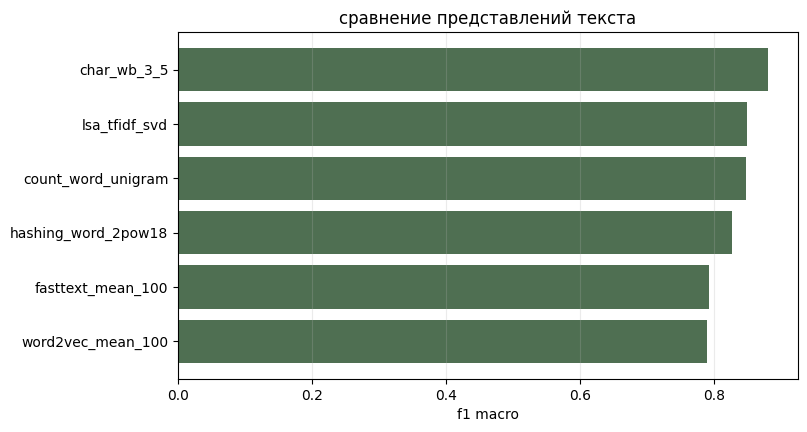

In [8]:
plot_df = embedding_results.dropna(subset=['f1_macro']).sort_values('f1_macro')
plt.figure(figsize=(8, 4.5))
plt.barh(plot_df['representation'], plot_df['f1_macro'], color='#4f6f52')
plt.xlabel('f1 macro')
plt.title('сравнение представлений текста')
plt.grid(axis='x', alpha=0.25)
plt.show()

лучший классический вариант смотрим по `f1_macro`. word2vec и fasttext нужны как проверка плотных эмбеддингов.

rnn baseline: bi-gru с embedding-слоем.

In [9]:
def run_bigru(epochs=8, batch_size=32, max_len=160):
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    counter = Counter()
    for text in x_train_text:
        counter.update(tokenize(text))
    vocab = {'<pad>': 0, '<unk>': 1}
    for word, _ in counter.most_common(30000 - len(vocab)):
        vocab[word] = len(vocab)

    def encode(text):
        ids = [vocab.get(tok, vocab['<unk>']) for tok in tokenize(text)[:max_len]]
        return ids + [vocab['<pad>']] * (max_len - len(ids))

    x_train = np.array([encode(text) for text in x_train_text])
    x_val = np.array([encode(text) for text in x_val_text])

    class RNNClassifier(nn.Module):
        def __init__(self, vocab_size, n_classes):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
            self.rnn = nn.GRU(128, 128, batch_first=True, bidirectional=True)
            self.dropout = nn.Dropout(0.25)
            self.fc = nn.Linear(256, n_classes)

        def forward(self, x):
            emb = self.embedding(x)
            _, h = self.rnn(emb)
            h = torch.cat([h[-2], h[-1]], dim=1)
            return self.fc(self.dropout(h))

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = RNNClassifier(len(vocab), len(le.classes_)).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.LongTensor(x_train), torch.LongTensor(y_train)), batch_size=batch_size, shuffle=True)
    val_x = torch.LongTensor(x_val).to(device)

    rows = []
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            losses.append(float(loss.detach().cpu()))
        model.eval()
        with torch.no_grad():
            pred = model(val_x).argmax(dim=1).cpu().numpy()
        rows.append({'epoch': epoch, 'loss': np.mean(losses), 'f1_macro': f1_score(y_val, pred, average='macro'), 'accuracy': accuracy_score(y_val, pred)})
    return pd.DataFrame(rows)

try:
    rnn_results = run_bigru(epochs=2)
except Exception as e:
    rnn_results = pd.DataFrame([{'model': 'bigru', 'status': 'not run', 'reason': str(e)}])
rnn_results

,epoch,loss,f1_macro,accuracy
0,1,1.173745,0.583593,0.605505
1,2,0.649918,0.743892,0.718043


transformer baseline: fine-tuning `cointegrated/rubert-tiny2` на наших темах.

In [10]:
def run_transformer(model_name='cointegrated/rubert-tiny2', epochs=1, batch_size=8, max_len=192):
    import torch
    from torch.utils.data import Dataset
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
    from transformers import logging as transformers_logging

    transformers_logging.set_verbosity_error()
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    class NewsDataset(Dataset):
        def __init__(self, texts, labels):
            self.enc = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len)
            self.labels = labels
        def __len__(self):
            return len(self.labels)
        def __getitem__(self, idx):
            item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
            item['labels'] = torch.tensor(int(self.labels[idx]))
            return item

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_))
    train_ds = NewsDataset(train['text'].astype(str), y_train)
    val_ds = NewsDataset(val['text'].astype(str), y_val)

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        pred = np.argmax(logits, axis=1)
        return {'f1_macro': f1_score(labels, pred, average='macro'), 'accuracy': accuracy_score(labels, pred)}

    args = TrainingArguments(
        output_dir=str(root / 'ML_Experiments' / 'checkpoint_6_transformer_tmp'),
        eval_strategy='epoch',
        save_strategy='no',
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        report_to=[],
        disable_tqdm=True,
        dataloader_pin_memory=False,
        logging_strategy='no',
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds, compute_metrics=compute_metrics)
    trainer.train()
    return trainer.evaluate()

In [11]:
import io
import contextlib
import warnings
import logging

try:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        logging.getLogger('huggingface_hub').setLevel(logging.ERROR)
        logging.getLogger('transformers').setLevel(logging.ERROR)
        hidden_output = io.StringIO()
        with contextlib.redirect_stdout(hidden_output), contextlib.redirect_stderr(hidden_output):
            transformer_metrics = run_transformer(epochs=1)
except Exception as e:
    transformer_metrics = {'error': str(e)}
transformer_metrics

{'eval_loss': 0.20327536761760712,
 'eval_f1_macro': 0.9598313655174275,
 'eval_accuracy': 0.963302752293578,
 'eval_runtime': 4.1956,
 'eval_samples_per_second': 389.698,
 'eval_steps_per_second': 48.861,
 'epoch': 1.0}

кластеризация в embedding space. kmeans считаем на всем корпусе, agglomerative на выборке.

In [12]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000, stop_words=STOP_WORDS)
x_sparse = vectorizer.fit_transform(df[TEXT_COL])
n_components = min(100, max(2, x_sparse.shape[1] - 1), max(2, x_sparse.shape[0] - 1))
x_emb = TruncatedSVD(n_components=n_components, random_state=42).fit_transform(x_sparse)
x_emb = normalize(x_emb)

zero_rows = np.where(np.linalg.norm(x_emb, axis=1) == 0)[0]
if len(zero_rows):
    x_emb[zero_rows, 0] = 1.0

y_true = LabelEncoder().fit_transform(df['topic'])
n_clusters = max(2, min(df['topic'].nunique(), math.floor(math.sqrt(len(df)))))

cluster_rows = []
labels_by_name = {}

kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
labels = kmeans.fit_predict(x_emb)
labels_by_name['kmeans'] = labels
cluster_rows.append({
    'clusterer': 'kmeans_full',
    'rows_used': len(df),
    'n_clusters': n_clusters,
    'silhouette_cosine': silhouette_score(x_emb, labels, metric='cosine'),
    'ari_vs_topic': adjusted_rand_score(y_true, labels),
    'nmi_vs_topic': normalized_mutual_info_score(y_true, labels),
    'cluster_sizes': dict(Counter(labels)),
})

sample_size = min(3000, len(df))
sample_idx = np.random.default_rng(42).choice(len(df), size=sample_size, replace=False)
x_sample = x_emb[sample_idx]
y_sample = y_true[sample_idx]

agg = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='average')
agg_labels = agg.fit_predict(x_sample)
cluster_rows.append({
    'clusterer': 'agglomerative_cosine_sample',
    'rows_used': sample_size,
    'n_clusters': n_clusters,
    'silhouette_cosine': silhouette_score(x_sample, agg_labels, metric='cosine'),
    'ari_vs_topic': adjusted_rand_score(y_sample, agg_labels),
    'nmi_vs_topic': normalized_mutual_info_score(y_sample, agg_labels),
    'cluster_sizes': dict(Counter(agg_labels)),
})

cluster_results = pd.DataFrame(cluster_rows)
cluster_results

,clusterer,rows_used,n_clusters,silhouette_cosine,ari_vs_topic,nmi_vs_topic,cluster_sizes
0,kmeans_full,10895,5,0.072348,0.179808,0.279225,"{2: 4624, 4: 1709, 3: 1916, 1: 733, 0: 1913}"
1,agglomerative_cosine_sample,3000,5,0.047007,0.089053,0.230009,"{0: 2655, 1: 262, 4: 57, 2: 14, 3: 12}"


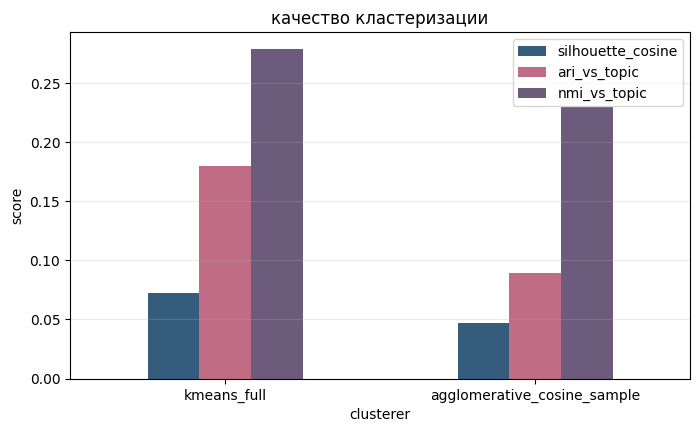

In [13]:
metric_df = cluster_results.set_index('clusterer')[['silhouette_cosine', 'ari_vs_topic', 'nmi_vs_topic']]
metric_df.plot(kind='bar', figsize=(8, 4.5), color=['#355c7d', '#c06c84', '#6c5b7b'])
plt.title('качество кластеризации')
plt.ylabel('score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.25)
plt.show()

кластеризация слабее классификации: часть кластеров все еще зависит от стиля каналов и оставшегося шума.

summary по кластерам: берем центральные тексты без служебных сообщений, ключевые слова без стоп-слов и extractive summary.

In [14]:
def top_terms_for_cluster(texts, labels, cluster, top_n=12):
    cluster_texts = texts[labels == cluster]
    if len(cluster_texts) == 0:
        return []
    local_vec = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=1, stop_words=STOP_WORDS)
    x = local_vec.fit_transform(cluster_texts)
    weights = np.asarray(x.mean(axis=0)).ravel()
    names = np.array(local_vec.get_feature_names_out())
    return names[np.argsort(weights)[::-1][:top_n]].tolist()

def is_service_text(text):
    text = str(text).lower()
    patterns = ['combot', 'has been banned', 'reason cas', 'startapp']
    return any(pattern in text for pattern in patterns)

def central_texts(texts, x, labels, cluster, top_n=5):
    indices = np.where(labels == cluster)[0]
    indices = np.array([i for i in indices if not is_service_text(texts.iloc[i])])
    if len(indices) == 0:
        return []
    cluster_x = x[indices]
    centroid = cluster_x.mean(axis=0, keepdims=True)
    scores = cosine_similarity(cluster_x, centroid).ravel()
    top_indices = indices[np.argsort(scores)[::-1][:top_n]]
    return [str(texts.iloc[i]) for i in top_indices]

def extractive_summary(texts, sentences_limit=4):
    sentences = []
    for text in texts:
        for sentence in str(text).replace('\\n', ' ').split('.'):
            sentence = sentence.strip()
            if len(sentence.split()) >= 5:
                sentences.append(sentence)
    if len(sentences) <= sentences_limit:
        return '. '.join(sentences)
    sent_vec = TfidfVectorizer(stop_words=STOP_WORDS)
    x = sent_vec.fit_transform(sentences)
    sim = cosine_similarity(x)
    np.fill_diagonal(sim, 0)
    scores = sim.sum(axis=1) / np.maximum((sim > 0).sum(axis=1), 1)
    selected = sorted(np.argsort(scores)[::-1][:sentences_limit])
    return '. '.join(sentences[i] for i in selected)

labels = labels_by_name['kmeans']
summary_rows = []
for cluster in sorted(set(labels)):
    mask = labels == cluster
    central = central_texts(df['text'], x_emb, labels, cluster, top_n=5)
    summary_rows.append({
        'cluster': int(cluster),
        'size': int(mask.sum()),
        'dominant_topic': df.loc[mask, 'topic'].mode().iloc[0],
        'top_terms': ', '.join(top_terms_for_cluster(df[TEXT_COL], labels, cluster)),
        'summary': extractive_summary(central),
        'example': central[0] if central else '',
    })

cluster_summaries = pd.DataFrame(summary_rows).sort_values('size', ascending=False)
cluster_summaries[['cluster', 'size', 'dominant_topic', 'top_terms', 'summary']].head(8)

,cluster,size,dominant_topic,top_terms,summary
2,2,4624,politics,"россии, сообщил, области, би, сообщили, человек, путин, также, украины, заявил, время, рф","Пограничная охрана Северной Карелии подтвердила, что у выдворенного из страны россиянина есть военное прошлое. **Оди..."
3,3,1916,politics,"сша, украине, украины, план, заявил, трамп, плана, россии, трампа, президента, мирного, президент",А так можно было?\n\n#ithumor
0,0,1913,it,"почему, ии, всё, просто, который, которые, автор, код, какие, ещё, данных, нужно","Заходишь в репозиторий OpenSSL, а там тебя встречают PERL, десятки сабмодулей и горы мусора. **Зато нет самого важно..."
4,4,1709,economy,"россии, году, компании, рбк, рублей, млрд, также, млн, forbes, которые, руб, будут",и составила 4% на 1 октября. **Как может работать новый режим доступа иностранцев к торгам и станет ли это катализат...
1,1,733,science,"ученые, которые, обнаружили, назад, тысяч, людей, пришли, выяснили, нашли, проанализировали, примерно, археологи","А у многих видов млекопитающих самки превосходят самцов по продолжительности жизни. Для сравнения, у птиц двумя разн..."


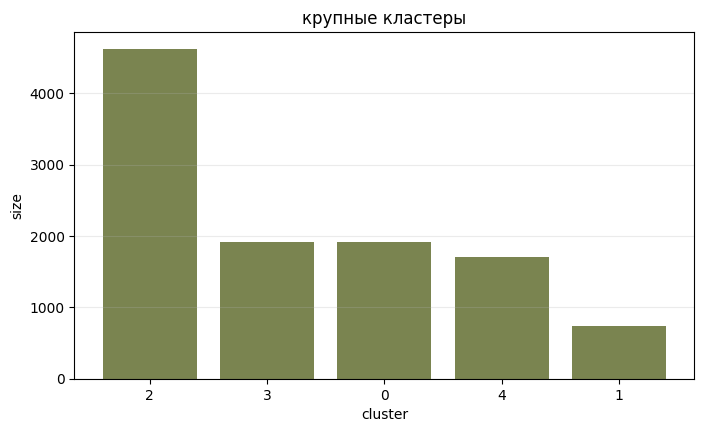

In [15]:
sizes = cluster_summaries.head(8)
plt.figure(figsize=(8, 4.5))
plt.bar(sizes['cluster'].astype(str), sizes['size'], color='#7a8450')
plt.xlabel('cluster')
plt.ylabel('size')
plt.title('крупные кластеры')
plt.grid(axis='y', alpha=0.25)
plt.show()

итог: добавили чистку шаблонов, сравнили новые признаки, проверили rnn, transformer, кластеры и summary.